In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from einops import rearrange, repeat
from einops.layers.torch import Rearrange, Reduce
from torch.utils.data import random_split, ConcatDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.cuda.is_available())

True


## 학습 모델

### Position Encoding

Sinusoidal Embedding 방식(Sine and Cosine 함수 사용)으로 Matrix 위치의 고유값 생성

n:빈도,주파수. 값 반복 주기를 정함

ViT 논문에서는 10,000을 사용

작은 sequence 환경에서는 n=100 이 좋은 경우도 있음

In [ ]:
def get_position_encoding(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d / 2)):
            denominator = np.power(n, 2 * i / d)
            P[k, 2 * i] = np.sin(k / denominator)
            P[k, 2 * i + 1] = np.cos(k / denominator)
    return P

n 값 변화에 따른 차이 비교

[[ 0.          1.          0.          1.        ]
 [ 0.84147098  0.54030231  0.09983342  0.99500417]
 [ 0.90929743 -0.41614684  0.19866933  0.98006658]
 [ 0.14112001 -0.9899925   0.29552021  0.95533649]]
[[ 0.          1.          0.          1.        ]
 [ 0.84147098  0.54030231  0.00999983  0.99995   ]
 [ 0.90929743 -0.41614684  0.01999867  0.99980001]
 [ 0.14112001 -0.9899925   0.0299955   0.99955003]]


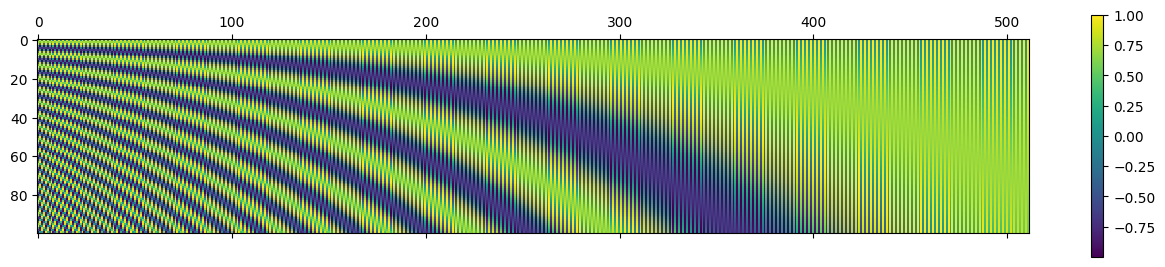

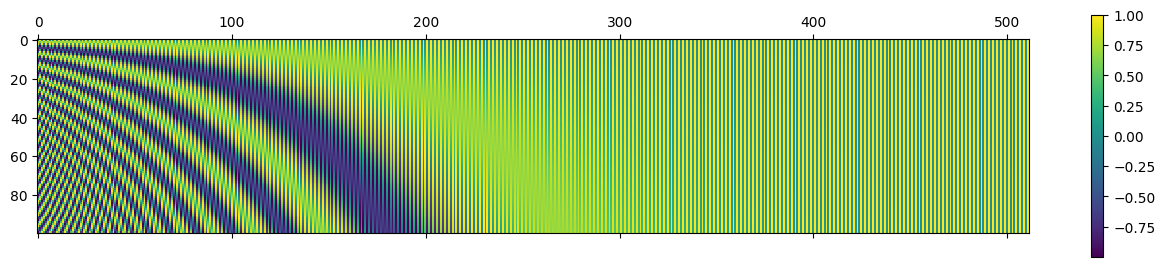

In [ ]:
P = get_position_encoding(seq_len=100, d=512, n=100)
cax = plt.matshow(P)
plt.gcf().colorbar(cax)

P = get_position_encoding(seq_len=100, d=512, n=10000)
cax = plt.matshow(P)
plt.gcf().colorbar(cax)

print(get_position_encoding(seq_len=4, d=4, n=100))
print(get_position_encoding(seq_len=4, d=4, n=10000))

### PatchEmbedding

이미지를 4개의 패치로 분할 하고, 각 패치를 벡터로 펼친 후 선형 변환을 적용하는 모듈

CIFAR 10의 경우, 1개의 이미지 [3, 32, 32]를 64개의 벡터 [64, 48]로 변형

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels: int = 3, patch_size: int = 16, emb_size: int = 768, img_size: int = 32):
        self.patch_size = patch_size
        super().__init__()

        # 이미지를 패치로 분할 하고, 각 패치를 벡터로 펼친 후 선형 변환을 적용하는 모듈
        self.projection = nn.Sequential(
            # 이미지를 패치로 분할하고, 각 패치를 벡터로 펼치는 과정
            # [64, 3, 32, 32] → [64, 64, 48] 16개 패치로 분할
            Rearrange('b c (h s1) (w s2) -> b (h w) (s1 s2 c)', s1=patch_size, s2=patch_size),

            # 각 패치를 emb_size 차원의 벡터로 변환하는 선형 계층
            # [64, 64, 48] → [64, 64, emb_size]
            nn.Linear(patch_size * patch_size * in_channels, emb_size)
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
        # Position(Sinusoidal) Embedding (cls_tokens 추가할 것을 고려 하여 +1)
        self.sinusoids_positions = torch.from_numpy(get_position_encoding((img_size // patch_size) ** 2 + 1, emb_size))

    def forward(self, x):
        b, _, _, _ = x.shape

        # 이미지를 패치로 분할
        x = self.projection(x)

        # Classification Token을 반복하여 입력의 배치 크기에 맞게 확장 (입력 앞에 추가하기 위한 단순 복사)
        # [64, 64, 384] → [64, 65, 384]
        cls_tokens = repeat(self.cls_token, '() n e -> b n e', b=b)
        x = torch.cat([cls_tokens, x], dim=1)

        # Position Embedding을 더함 (element wise sum)
        x += self.sinusoids_positions.to(device=x.device, dtype=x.dtype)
        return x

### MultiHeadAttention

Transformer의 핵심 모듈

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size: int = 768, num_heads: int = 12, dropout: float = 0):
        super().__init__()
        self.emb_size = emb_size
        self.num_heads = num_heads
        # 각각의 Queries, Keys, Values를 위한 Linear 레이어
        self.keys = nn.Linear(emb_size, emb_size)
        self.queries = nn.Linear(emb_size, emb_size)
        self.values = nn.Linear(emb_size, emb_size)
        # Attention 이후에 적용되는 dropout
        self.att_drop = nn.Dropout(dropout)
        # Multi Head Attention 이후에 적용되는 Linear 레이어
        self.projection = nn.Linear(emb_size, emb_size)
        # 차원이 크면 Query와 Key의 내적값이 커져서 Vanishing Gradients 발생
        # 이를 방지하기위해 차원수의 루트값으로 나눠줌 (Normalize)
        self.scaling = (self.emb_size // num_heads) ** -0.5

    def forward(self, x):
        # 입력값에 Q, K, V Weight 적용한 후 Head 만큼 나눔
        queries = rearrange(self.queries(x), 'b n (h d) -> b h n d', h=self.num_heads)
        keys = rearrange(self.keys(x), 'b n (h d) -> b h n d', h=self.num_heads)
        values = rearrange(self.values(x), 'b n (h d) -> b h n d', h=self.num_heads)
        # Queries와 Keys의 Dot Product를 계산하여 Attention Scores를 얻음
        energy = torch.einsum('bhqd, bhkd -> bhqk', queries, keys)  # batch, num_heads, query_len, key_len
        # Attention Scores의 마지막 차원에 Softmax 확률 계산
        # Attention Score Matrix 전체에 대한 계산이 아닌 벡터별 계산
        att = F.softmax(energy * self.scaling, dim=-1)
        att = self.att_drop(att)
        # Attention Scores를 이용하여 Values에 가중치를 적용
        out = torch.einsum('bhal, bhlv -> bhav ', att, values)  # a: query_len, l: key_len, v: value_dim
        # 결과를 원래의 형태로 재배열
        out = rearrange(out, 'b h n d -> b n (h d)')
        # 최종 Linear 레이어를 통과
        out = self.projection(out)
        return out

### ResidualAdd

Transformer 내부 Residual 구성을 위한 Class

In [ ]:
class ResidualAdd(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        res = x
        x = self.fn(x, **kwargs)
        x += res
        return x

### FeedForwardBlock

Multi Head Attention 직후에 적용하는 MLP

In [ ]:
class FeedForwardBlock(nn.Module):
    def __init__(self, emb_size: int, expansion: int = 4, drop_p: float = 0.):
        super().__init__()
        self.linear1 = nn.Linear(emb_size, expansion * emb_size)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(drop_p)
        self.linear2 = nn.Linear(expansion * emb_size, emb_size)

    def forward(self, x):
        x = self.linear1(x)
        x = self.gelu(x)
        x = self.dropout(x)
        return self.linear2(x)

### TransformerEncoderBlock

위 Class들을 활용하여 하나의 Transformer Block 구성

In [ ]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_size: int = 768, drop_p: float = 0., forward_expansion: int = 4, forward_drop_p: float = 0.,
                 **kwargs):
        super().__init__()
        self.layer1 = ResidualAdd(nn.Sequential(
            nn.LayerNorm(emb_size),
            MultiHeadAttention(emb_size, **kwargs),
            nn.Dropout(drop_p)
        ))
        self.layer2 = ResidualAdd(nn.Sequential(
            nn.LayerNorm(emb_size),
            FeedForwardBlock(
                emb_size, expansion=forward_expansion, drop_p=forward_drop_p),
            nn.Dropout(drop_p)
        ))

    def forward(self, x, **kwargs):
        x = self.layer1(x, **kwargs)
        x = self.layer2(x, **kwargs)
        return x

### TransformerEncoder

Transformer Block을 반복하여 이어 붙여 Encoder 구성
<br><br>
(참고) Transformer Block 수에 따른 모델 표기법

B(ase)=12, L(arge)=24, H(uge)=32

ViT-B/16 : 입력 이미지를 16x16 Size의 Patch로 나누고 12개의 Transformer Block을 사용한 Vision Transformer

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, depth: int = 12, **kwargs):
        super().__init__()
        # nn.ModuleList는 nn.Sequential과는 달리 forward가 없어 Loop를 돌며 일일이 호출해줘야 함
        self.blocks = nn.ModuleList([TransformerEncoderBlock(**kwargs) for _ in range(depth)])

    def forward(self, x, **kwargs):
        for block in self.blocks:
            x = block(x, **kwargs)
        return x

### ClassificationHead

TransformerEncoder 결과 값중 Classification Token 위치에 해당하는 값만 분류에 활용


In [ ]:
class ClassificationHead(nn.Module):
    def __init__(self, emb_size: int = 768, n_classes: int = 10):
        super().__init__()
        # Layer Normalization 레이어
        self.layer_norm = nn.LayerNorm(emb_size)
        # 최종 분류를 위한 Linear 레이어
        self.linear = nn.Linear(emb_size, n_classes)

    def forward(self, x):
        # 첫 번째 토큰 (CLS 토큰)만 사용
        x = x[:, 0]
        # Layer Normalization 적용
        x = self.layer_norm(x)
        # Linear 레이어를 통해 최종 분류 결과 반환
        return self.linear(x)

### ViT

In [ ]:
class ViT(nn.Module):
    def __init__(self, in_channels: int = 3, patch_size: int = 16, emb_size: int = 768, img_size: int = 32,
                 depth: int = 12, n_classes: int = 10, **kwargs):
        super().__init__()
        self.patch_embedding = PatchEmbedding(in_channels, patch_size, emb_size, img_size)
        self.transformer_encoder = TransformerEncoder(depth, emb_size=emb_size, **kwargs)
        self.classification_head = ClassificationHead(emb_size, n_classes)

    def forward(self, x):
        x = self.patch_embedding(x)
        x = self.transformer_encoder(x)
        return self.classification_head(x)

## 학습 코드

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_model = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model = model.state_dict()
        else:
            self.counter += 1
        return self.counter >= self.patience

In [ ]:
def train(net, train_loader, val_loader, writer, learning_rate=1e-3, eta_min=1e-5, weight_decay=1e-4):
    early_stopping = EarlyStopping(80, 0)

    # Loss Function, Optimizer 정의
    # criterion = nn.CrossEntropyLoss()
    train_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    val_criterion = nn.CrossEntropyLoss(label_smoothing=0.1, reduction='sum')  # Validation loss 계산용

    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
    # optimizer = torch.optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=600, eta_min=eta_min)

    # 모델 훈련
    for epoch in tqdm(range(600)):  # 데이터셋을 여러번 반복
        net.train()
        running_loss = 0.0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs = inputs.to(device)  # Tensor (64, 3, 32, 32)
            labels = labels.to(device)  # Tensor (64)

            # Gradient를 0으로 만든 후
            optimizer.zero_grad()

            # 순전파 + 역전파 + 최적화
            outputs = net(inputs)  # Tensor (64, 10)
            loss = train_criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # 통계 출력
            running_loss += loss.item()
            if (i + 1) % 200 == 0:  # 200 Mini Batch 마다 출력
                # print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 200:.3f}')
                # TensorBoard에 Loss 기록
                writer.add_scalar('training loss', running_loss / 200, epoch * len(train_loader) + i)
                running_loss = 0.0

        # Validation
        net.eval()
        val_loss = 0.0
        num_samples = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = net(inputs)
                loss = val_criterion(outputs, labels)
                val_loss += loss.item()
                num_samples += labels.size(0)

        val_loss /= num_samples
        writer.add_scalar('validation loss', val_loss, epoch)
        # print(f'[{epoch + 1}, Validation] loss: {val_loss:.3f}, LR: {scheduler.get_last_lr()[0]:.6f}')
        scheduler.step()

        # Check early stopping condition
        if early_stopping(val_loss, net):
            print('Early stopping triggered.')
            break

    print('Training finished.')
    net.load_state_dict(early_stopping.best_model)

    return net

In [ ]:
def evaluate(net, test_loader):
    net.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for inputs, labels in test_loader:
            inputs = inputs.to(device)  # Tensor (64, 3, 32, 32)
            labels = labels.to(device)  # Tensor (64)

            outputs = net(inputs)  # Tensor (64, 10)
            _, predicted = torch.max(outputs.detach(), 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

## 학습 Data 준비

In [ ]:
transform = transforms.Compose([
    # 이미지를 모서리 방향으로 4픽셀 padding해서 40×40으로 만든 뒤, 그 중에서 무작위 위치에서 32×32로 잘라냄
    # 모델이 물체의 위치 변화(translation)에 더 강건해짐
    transforms.RandomCrop(32, padding=4),

    transforms.RandomHorizontalFlip(),

    # CIFAR-10 데이터셋에 맞게 선택된 20+개 augmentation 연산 중에서 사전에 학습된 최적 조합(정책)을 무작위로 적용
    # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.AutoAugmentPolicy.html
    transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.CIFAR10),

    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 이미지 정규화
])

# 데이터셋 로드
data_set = torchvision.datasets.CIFAR10(root='./data/', train=True, download=True, transform=transform)

# 학습 및 검증 데이터셋으로 분할
train_set, val_set = random_split(data_set, [40000, 10000])

# CIFAR10 훈련 데이터셋 로드
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

test_set = torchvision.datasets.CIFAR10(root='./data/', train=False, download=True, transform=test_transform)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 170M/170M [00:04<00:00, 41.3MB/s]


## 학습

In [ ]:
models = {
    # 'ViT-B-2': ViT(depth=6, num_heads=8, patch_size=2, emb_size=48).to(device),
    'ViT-B-4': ViT(depth=7, num_heads=4, patch_size=4, emb_size=384).to(device),
    # 'ViT-B-8': ViT(depth=2, num_heads=8, patch_size=8, emb_size=192).to(device),
    # 'ViT-B-16': ViT(depth=2, num_heads=8, patch_size=16, emb_size=768).to(device),
    # 'ViT-B-16': ViT(depth=12, num_heads=12, patch_size=16, emb_size=768).to(device),
    # 'ViT-L-16': ViT(depth=24, num_heads=16, patch_size=16, emb_size=1024).to(device),
    # 'ViT-H-16': ViT(depth=32, num_heads=16, patch_size=16, emb_size=1280).to(device)
}

In [ ]:
results = {}
for name, model in models.items():
    print(f'Training and evaluating {name}...')
    writer = SummaryWriter(f'./cifar10-{name}')  # TensorBoard 설정
    model = train(model, train_loader, val_loader, writer, learning_rate=1e-4, eta_min=1e-5, weight_decay=5e-5)
    torch.save(model, f'./cifar10-{name}.pt')
    writer.close()  # TensorBoard 종료
    results[name] = evaluate(model, test_loader)

# 결과 출력
print('Model Evaluation Results:')
for name, accuracy in results.items():
    print(f'{name}: {accuracy:.2f}%')

Training and evaluating ViT-B-4...


 86%|████████▌ | 516/600 [5:34:58<54:31, 38.95s/it]

Early stopping triggered.
Training finished.


Model Evaluation Results:
ViT-B-4: 88.93%


### 학습간 Loss 비교

In [ ]:
# TensorBoard 결과 출력
%load_ext tensorboard
%tensorboard --logdir=./

## 결과

### 정확도

### 모델별 파라미터 수

In [ ]:
!pip install torchinfo
from torchinfo import summary

for name, model in models.items():
    print(summary(model, input_size=(64, 3, 32, 32), device=device))

Layer (type:depth-idx)                                  Output Shape              Param #
ViT                                                     [64, 10]                  --
├─PatchEmbedding: 1-1                                   [64, 65, 384]             384
│    └─Sequential: 2-1                                  [64, 64, 384]             --
│    │    └─Rearrange: 3-1                              [64, 64, 48]              --
│    │    └─Linear: 3-2                                 [64, 64, 384]             18,816
├─TransformerEncoder: 1-2                               [64, 65, 384]             --
│    └─ModuleList: 2-2                                  --                        --
│    │    └─TransformerEncoderBlock: 3-3                [64, 65, 384]             1,774,464
│    │    └─TransformerEncoderBlock: 3-4                [64, 65, 384]             1,774,464
│    │    └─TransformerEncoderBlock: 3-5                [64, 65, 384]             1,774,464
│    │    └─TransformerEncoderBloc

In [ ]:
from google.colab import runtime
import time

time.sleep(30)
runtime.unassign()